# Import and read all the csv files

In [24]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:

# Step 1: Define the folder containing the CSV files
folder_path = 'Charging_data/'  # Replace with your folder path

# Step 2: Get a list of all CSV files in the folder
csv_files = [file for file in os.listdir(folder_path) if file.endswith('.csv')]

# Step 3: Read each CSV file into a DataFrame
df_list = []
for file in csv_files:
    file_path = os.path.join(folder_path, file)
    df = pd.read_csv(file_path)
    df_list.append(df)

# Step 4: Concatenate all DataFrames into one
combined_df = pd.concat(df_list, ignore_index=True)

# Step 5: Display or use the combined DataFrame
combined_df.dropna(subset = ['Local Charge Start Time','Local Charge End Time'], inplace=True)
combined_df = combined_df.reset_index()


combined_df['Local Charge Start Time'] = pd.to_datetime(combined_df['Local Charge Start Time'], format='%m/%d/%Y %H:%M')
combined_df['Local Charge End Time'] = pd.to_datetime(combined_df['Local Charge End Time'], format='%m/%d/%Y %H:%M')

In [5]:
print(type(combined_df['Local Charge End Time'][0]))
print(len(combined_df))

combined_df['Time charging'] = combined_df['Local Charge End Time'] - combined_df['Local Charge Start Time']
print(combined_df['Time charging'])

# Step 2: Convert the Series to timedelta
timedelta_series = pd.to_timedelta(combined_df['Time charging'])

# Step 3: Extract the total number of minutes
minutes_series = timedelta_series.dt.total_seconds() / 3600

<class 'pandas._libs.tslibs.timestamps.Timestamp'>
9320
0      0 days 00:21:00
1      0 days 00:04:00
2      0 days 05:09:00
3      0 days 00:55:00
4      0 days 00:35:00
             ...      
9315   0 days 00:13:00
9316   0 days 06:43:00
9317   0 days 00:02:00
9318   0 days 00:49:00
9319   0 days 03:54:00
Name: Time charging, Length: 9320, dtype: timedelta64[ns]


(array([7.755e+03, 6.750e+02, 3.000e+02, 2.320e+02, 1.910e+02, 1.050e+02,
        4.300e+01, 1.400e+01, 4.000e+00, 1.000e+00]),
 array([ 0.  ,  1.19,  2.38,  3.57,  4.76,  5.95,  7.14,  8.33,  9.52,
        10.71, 11.9 ]),
 <BarContainer object of 10 artists>)

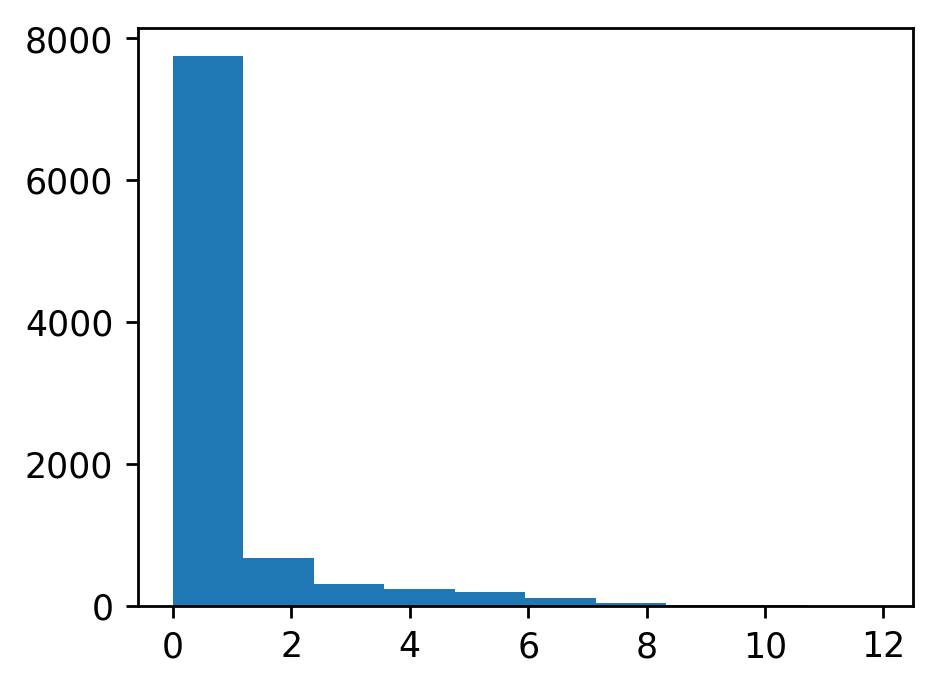

In [6]:
fig, ax = plt.subplots(figsize = (4,3), dpi = 250)

ax.hist(minutes_series)

In [20]:
df_NREL = pd.read_csv('Charging_data/NREL/data_for_fleet_dna_delivery_vans.csv')



df_NREL['start_ts']= pd.to_datetime(df_NREL['start_ts'])
df_NREL['end_ts']= pd.to_datetime(df_NREL['end_ts'])
# Ensure the DataFrame is sorted by V_id and Start_ts
df_NREL = df_NREL.sort_values(by=['vid', 'start_ts'])

# Calculate the rolling difference for each V_id
df_NREL['Rolling_diff'] = (df_NREL.groupby('vid')['start_ts'].shift(-1) - df_NREL['end_ts']).dt.total_seconds() / 3600


print(df_NREL[['distance_total', 'absolute_time_duration_hrs', 'Rolling_diff']][0:50])

df_to_write = df_NREL[['vid', 'start_ts','end_ts', 'distance_total', 'absolute_time_duration_hrs', 'Rolling_diff']]
df_to_write.to_csv('Charging_data/NREL/data_for_fleet_dna_delivery_vans_shift.csv')

     distance_total  absolute_time_duration_hrs  Rolling_diff
272       37.495290                   23.890278      0.119444
273        6.079517                   17.063611     46.453056
274       35.452443                    8.382500      0.110278
275       31.577050                   23.844722     39.736944
276       27.676593                    8.298056      0.138056
277        5.925647                    0.643333           NaN
0         67.535063                    8.322500     15.625000
1         66.972544                    8.398056      4.163333
2         64.851790                   19.760278     97.086667
3         72.198676                   23.233056      4.821389
4         48.697382                   18.915000           NaN
266       12.538434                   22.204444           NaN
5         34.936703                   21.004167     14.993056
6         38.211634                    9.267222     52.585000
7         41.403566                   19.206667     14.996944
8       

11.249138400855578
4.525575972497225


(array([ 51.,  28.,  41.,  43.,  92., 198., 147.,   8.,   3.,   1.]),
 array([-2.46675971, -1.93933353, -1.41190734, -0.88448116, -0.35705497,
         0.17037121,  0.6977974 ,  1.22522358,  1.75264977,  2.28007595,
         2.80750214]),
 <BarContainer object of 10 artists>)

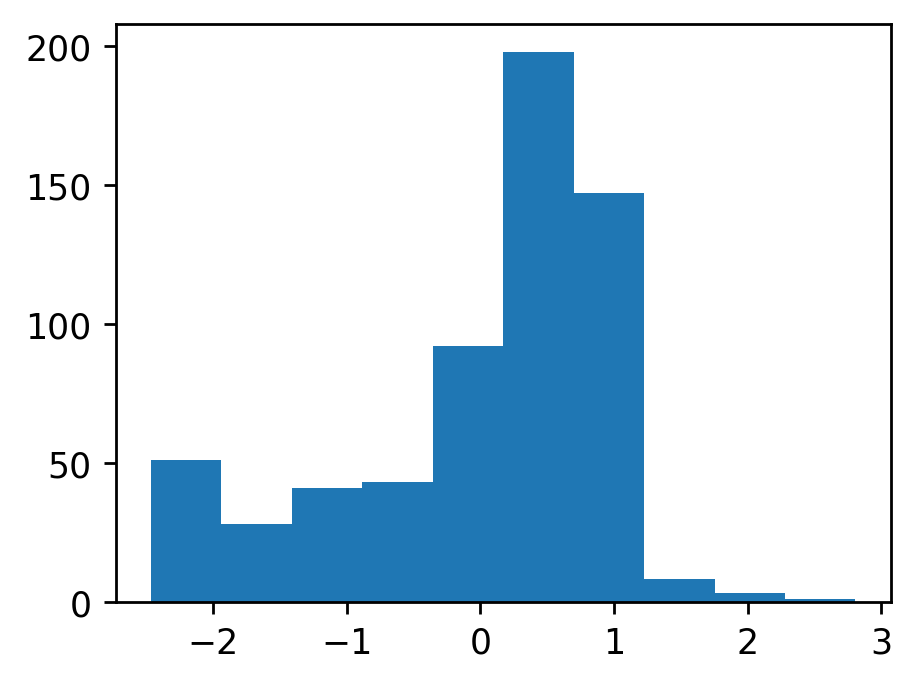

In [27]:
df_to_write = df_to_write[df_to_write['Rolling_diff'] <24]

print(np.mean(df_to_write['Rolling_diff']))
print(np.std(df_to_write['Rolling_diff']))
df_to_write['Z-score parked time'] = stats.zscore(df_to_write['Rolling_diff'])

df_to_write.to_csv('Charging_data/NREL/data_for_fleet_dna_delivery_vans_shift_filter.csv')

fig, ax = plt.subplots(figsize = (4,3), dpi = 250)

ax.hist(df_to_write['Z-score parked time'])

(array([ 51.,  28.,  41.,  43.,  92., 198., 147.,   8.,   3.,   1.]),
 array([ 0.08562991,  2.47253718,  4.85944445,  7.24635172,  9.63325899,
        12.02016626, 14.40707353, 16.7939808 , 19.18088807, 21.56779535,
        23.95470262]),
 <BarContainer object of 10 artists>)

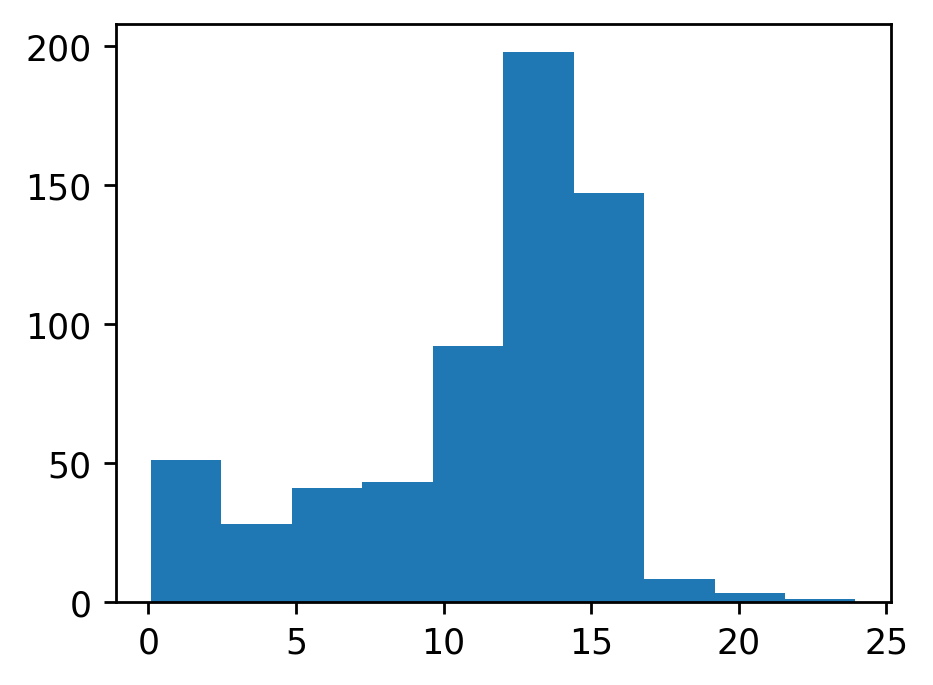

In [28]:
fig, ax = plt.subplots(figsize = (4,3), dpi = 250)

ax.hist(df_to_write['Rolling_diff'])

84
612


/var/folders/sc/srskfqx51lg6fw73v_l70gtc0000gn/T/ipykernel_54182/3100276817.py:9: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize = (4,3), dpi = 250)


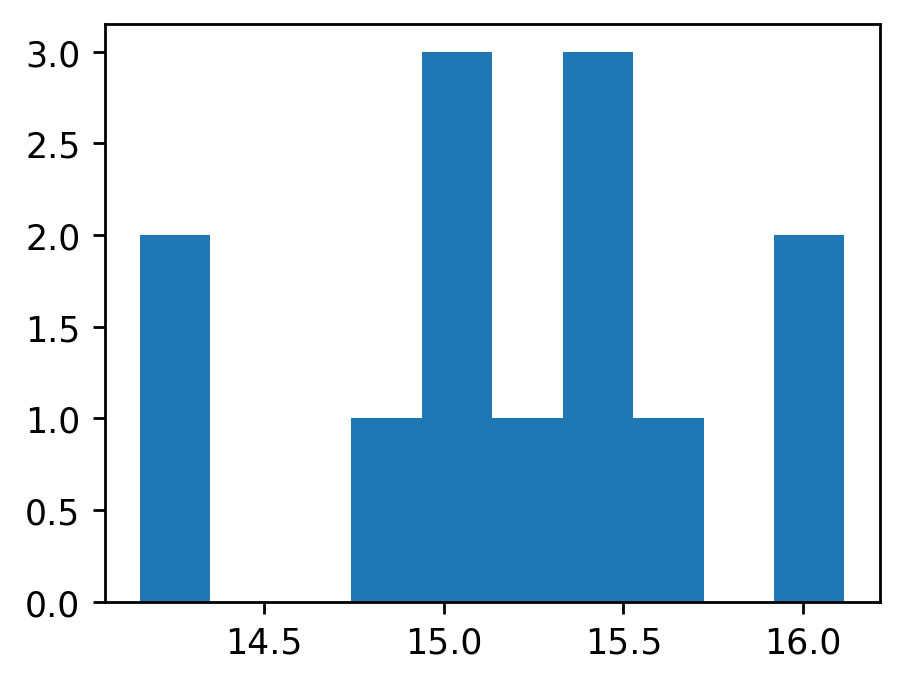

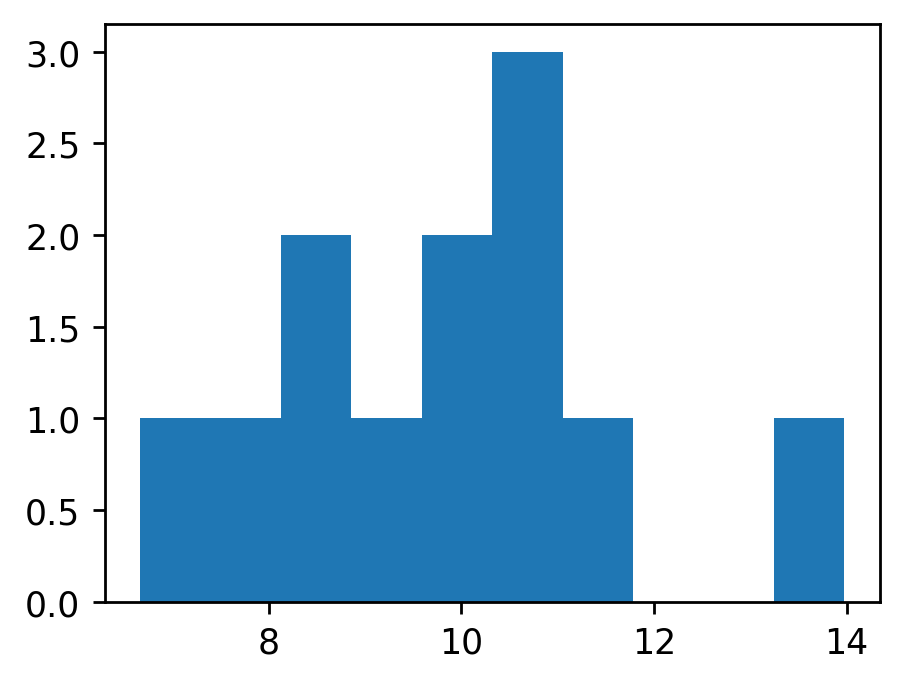

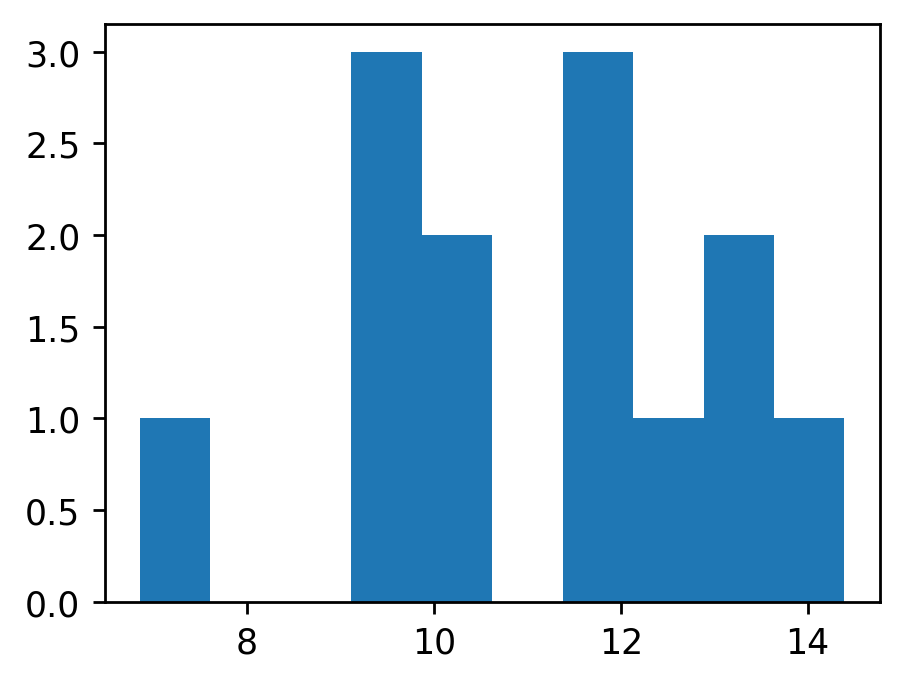

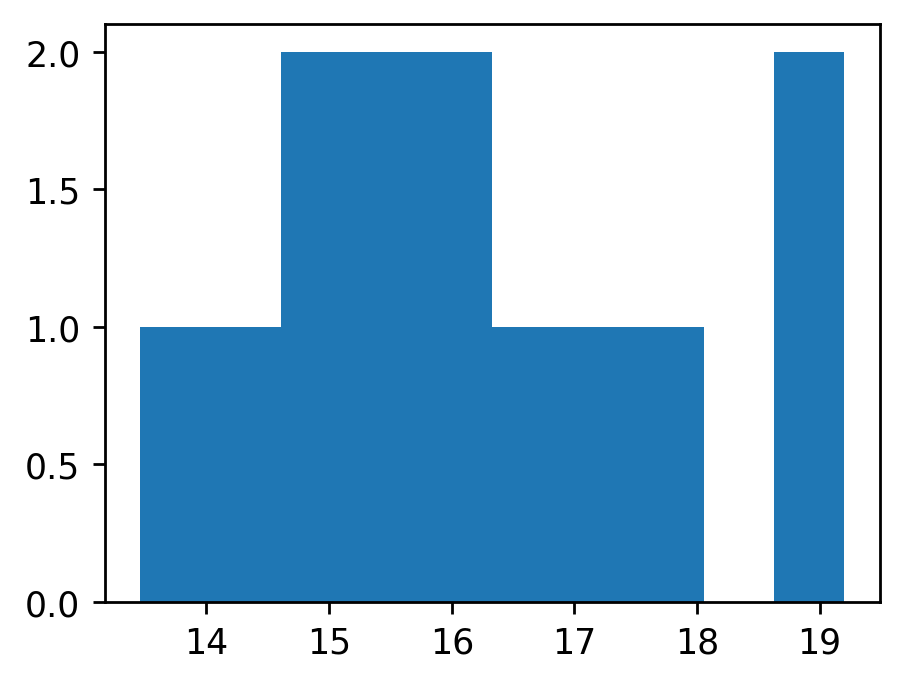

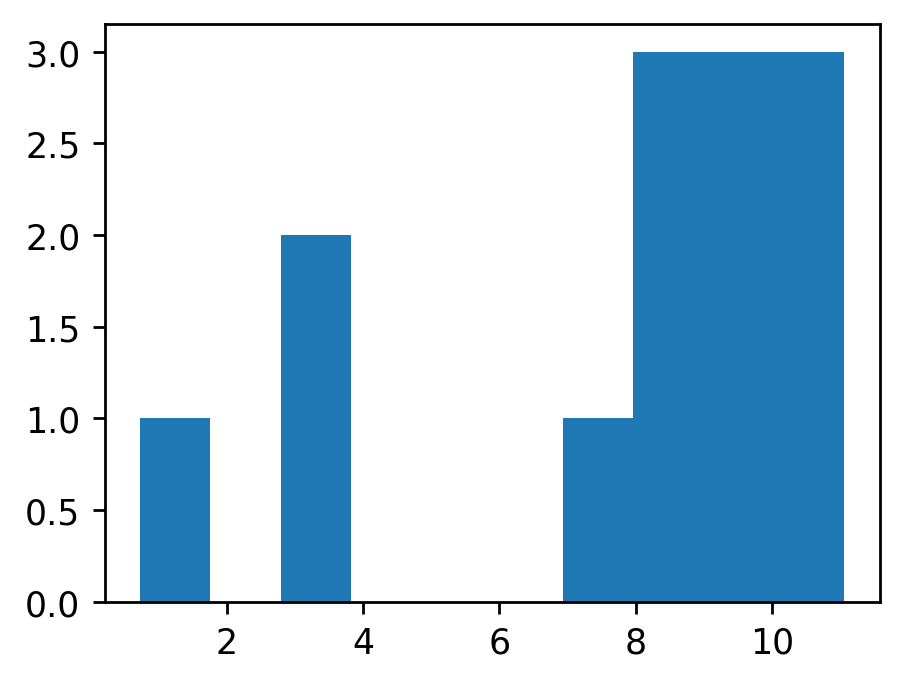

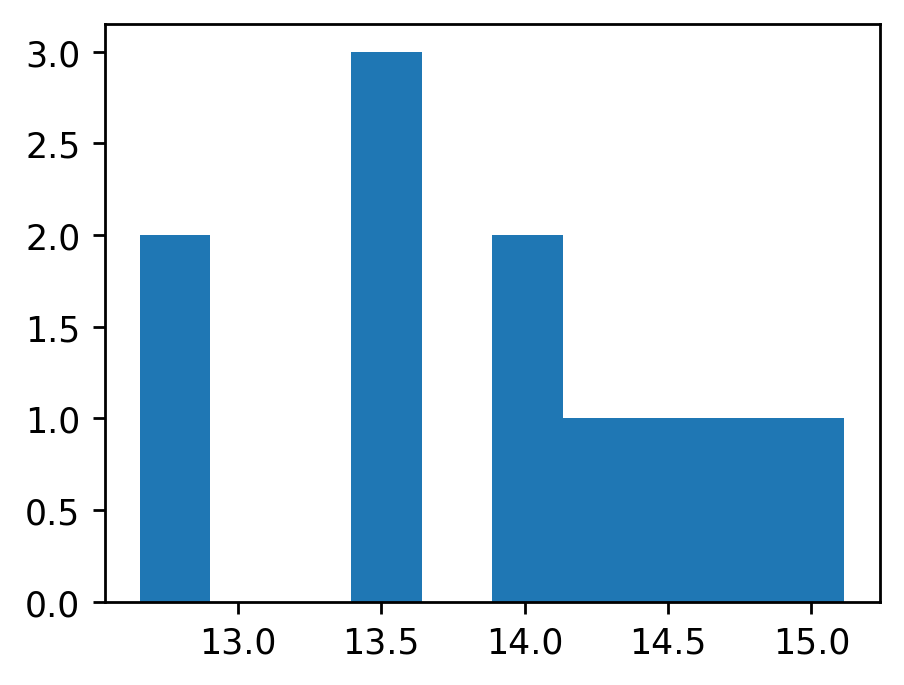

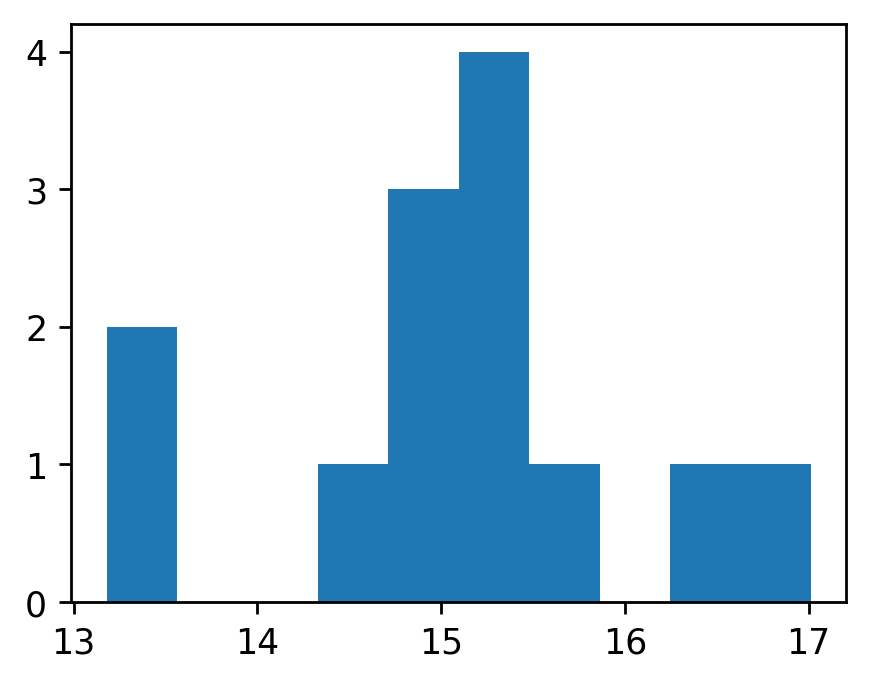

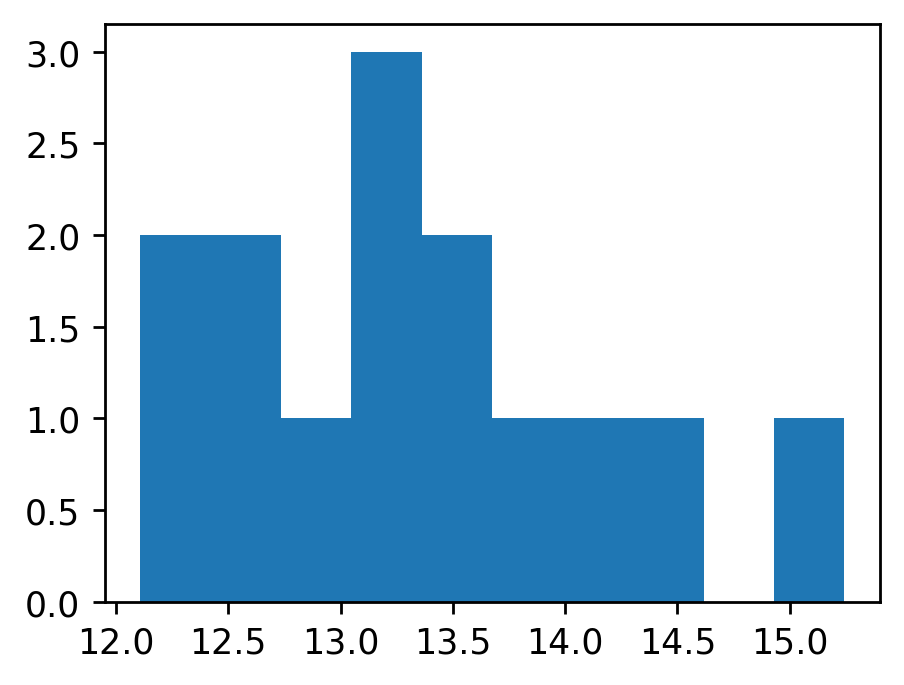

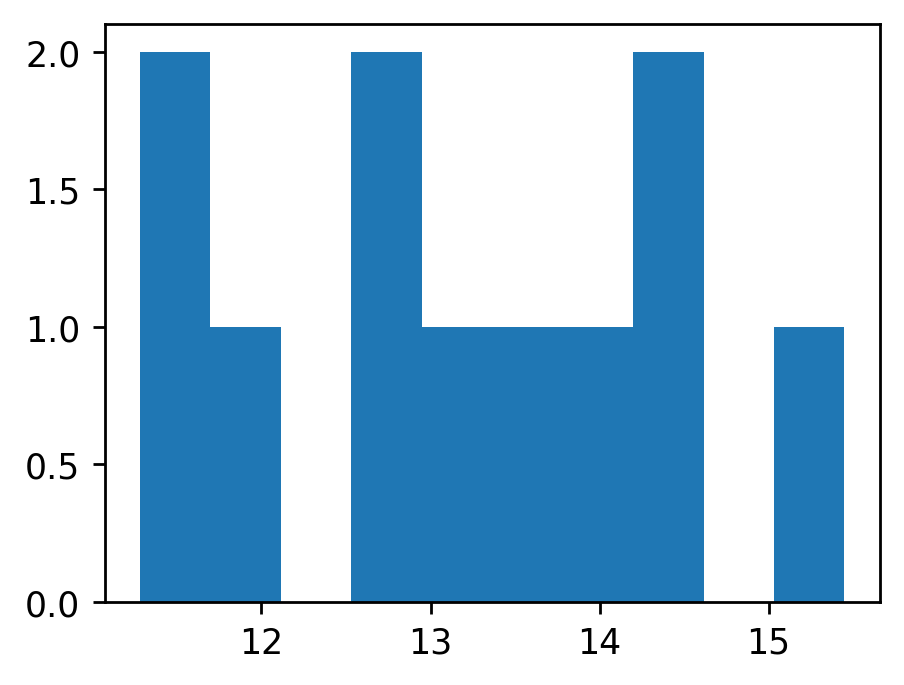

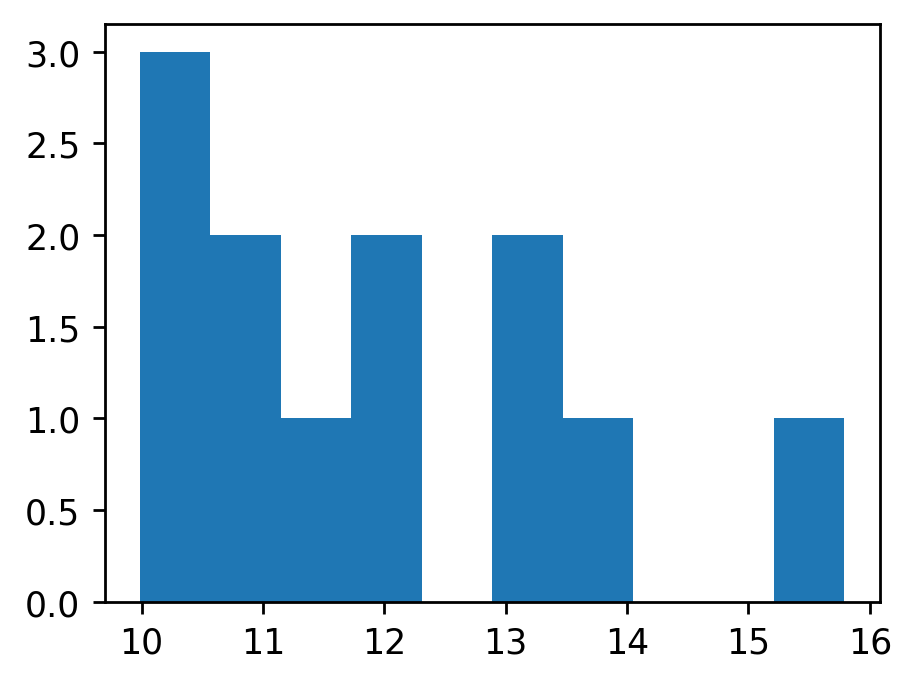

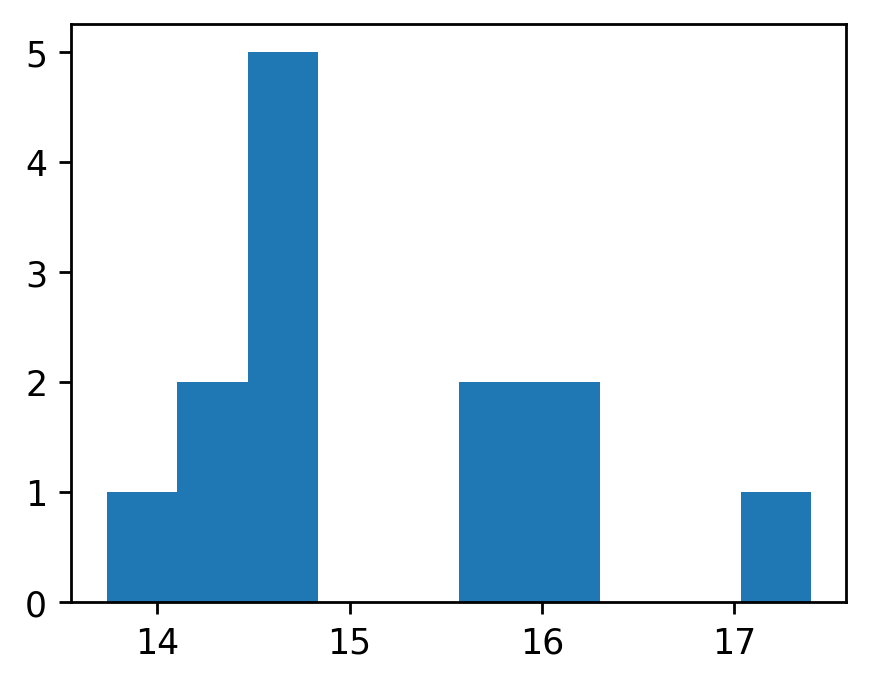

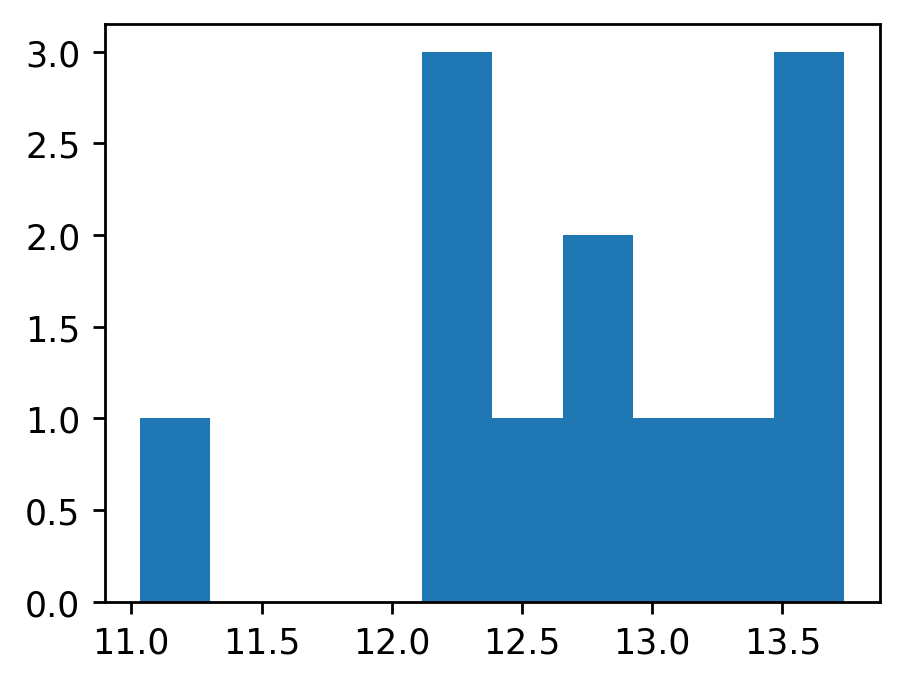

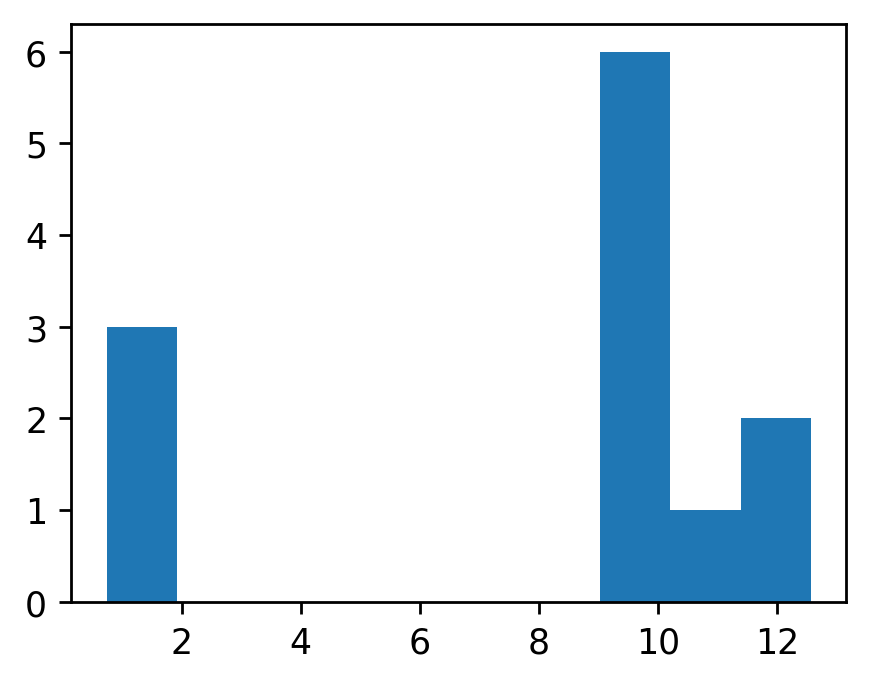

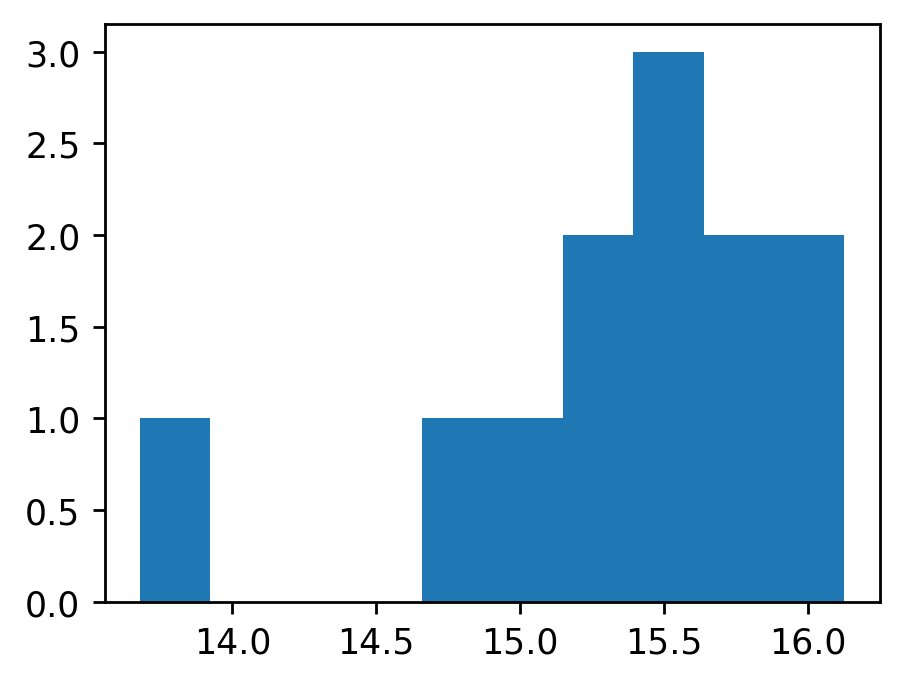

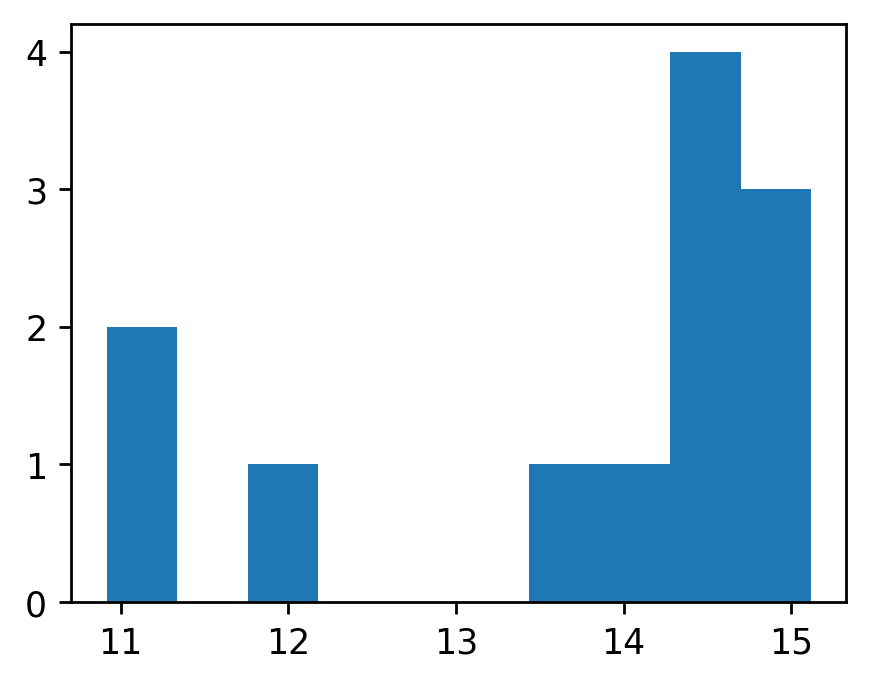

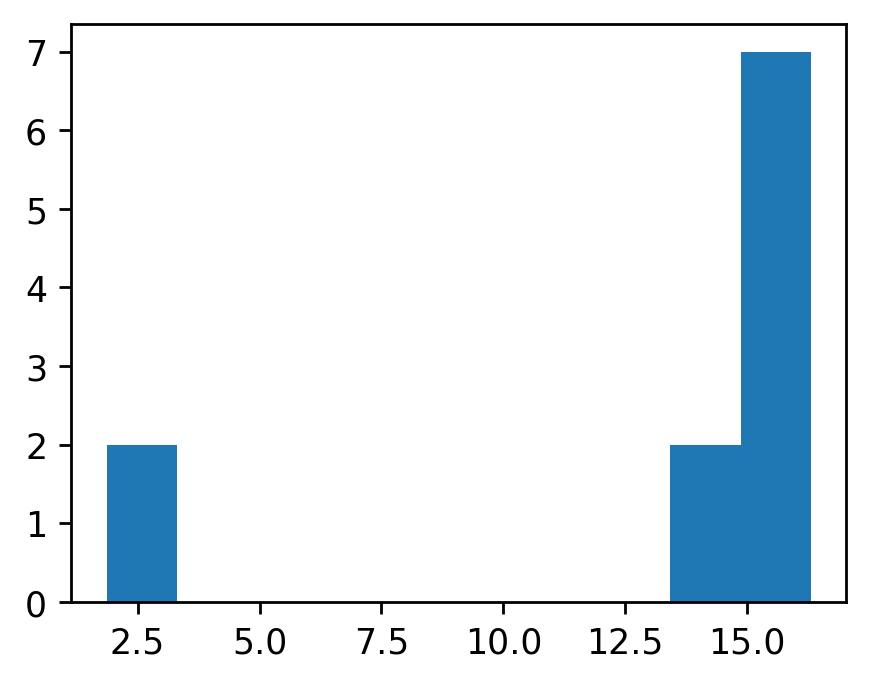

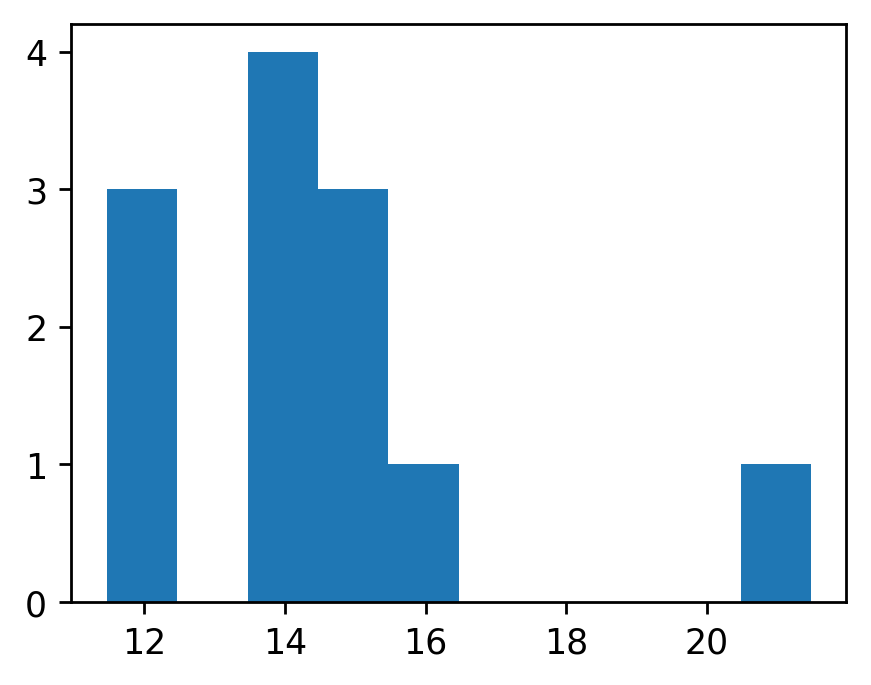

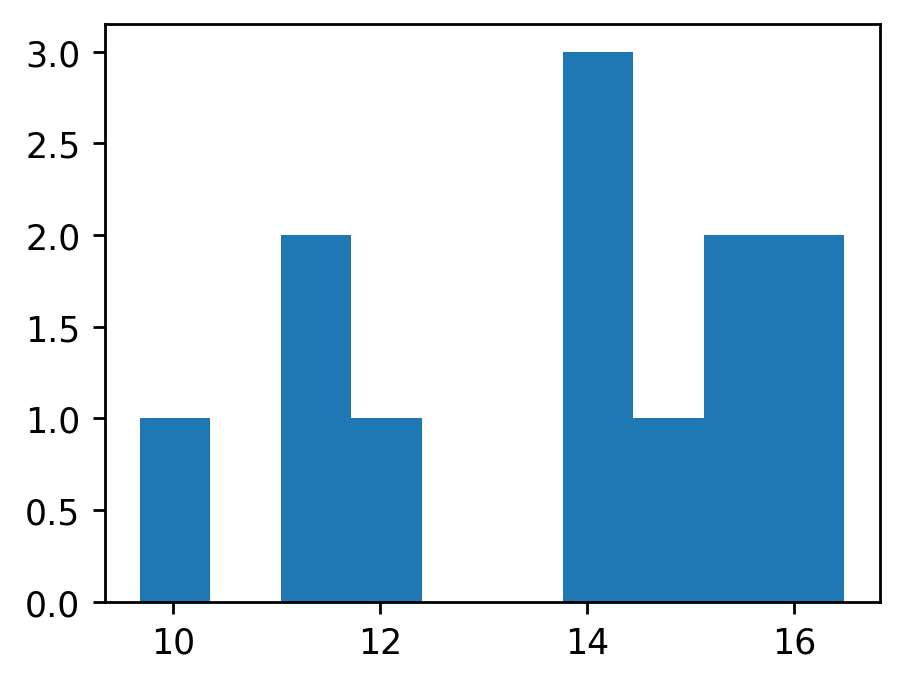

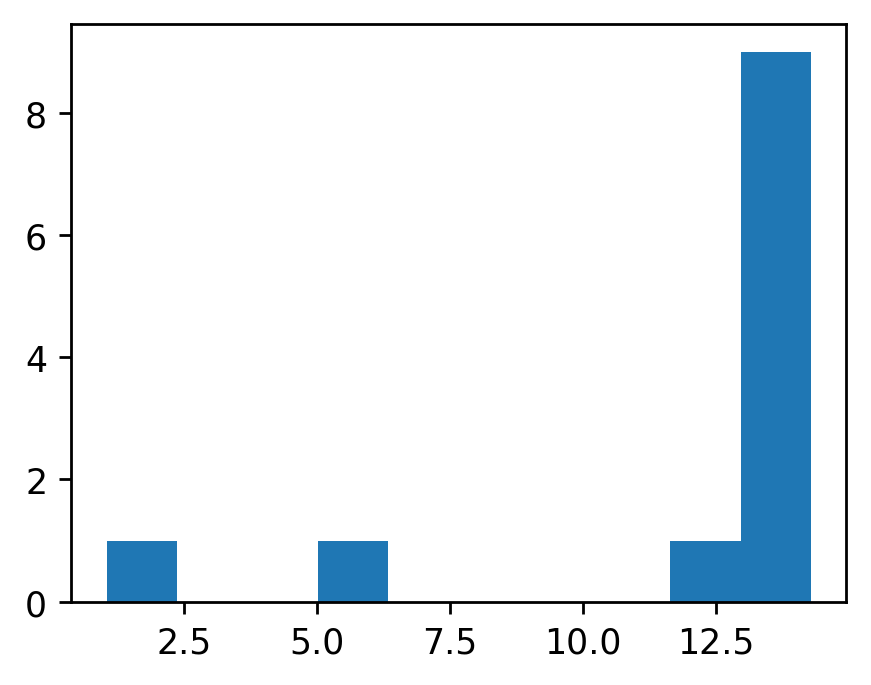

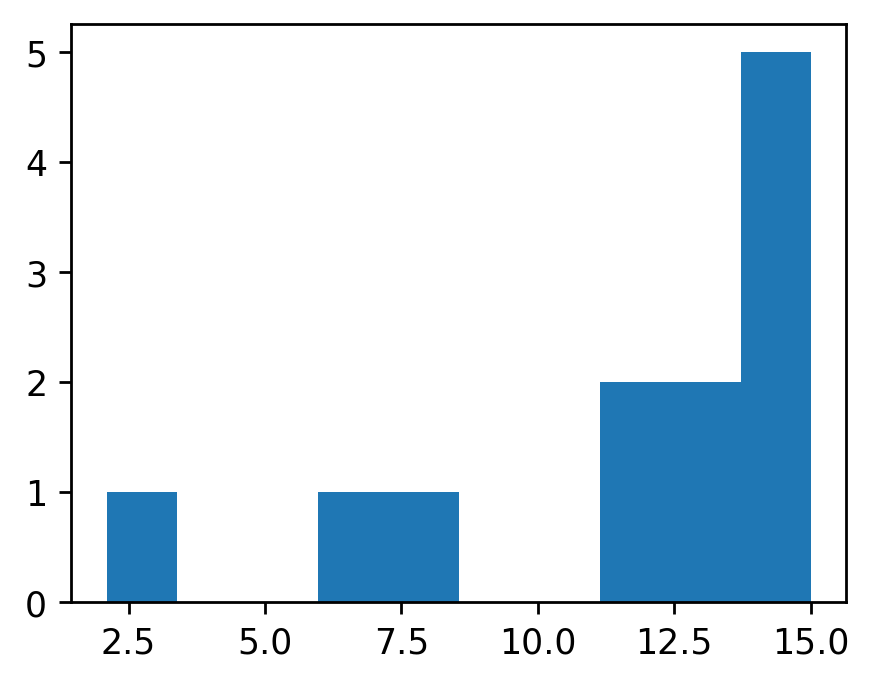

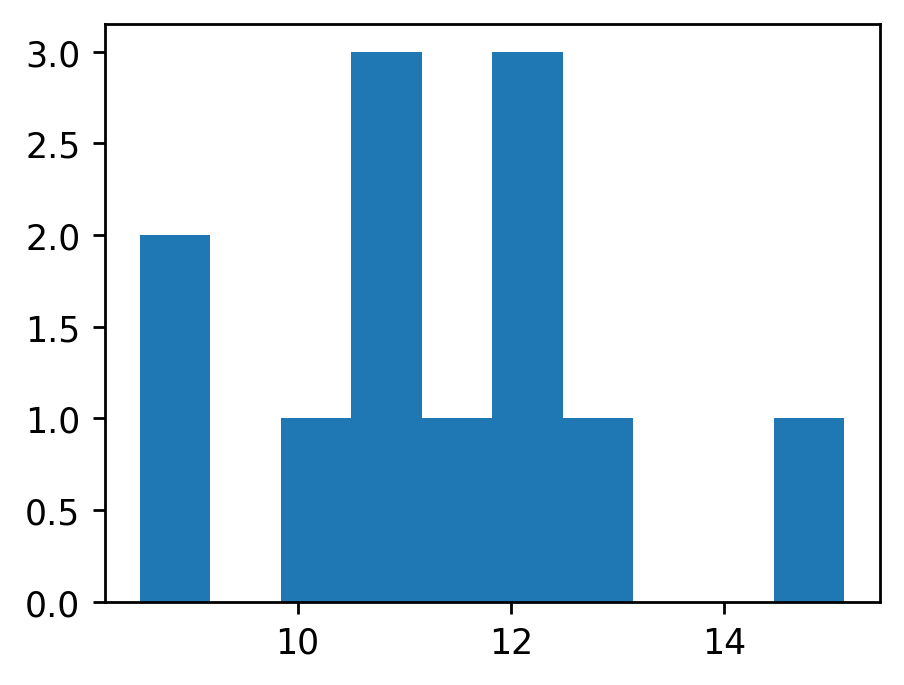

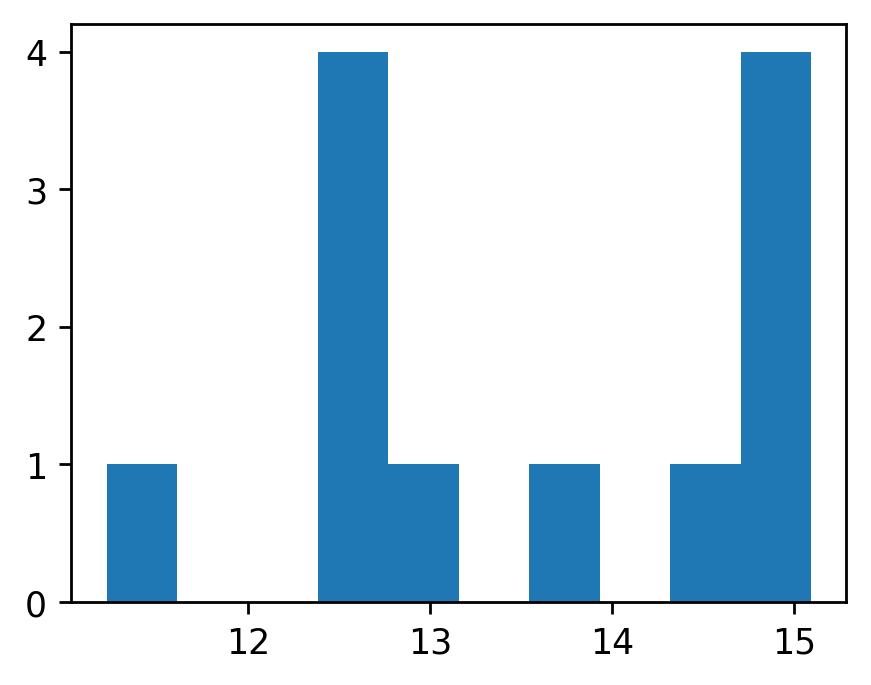

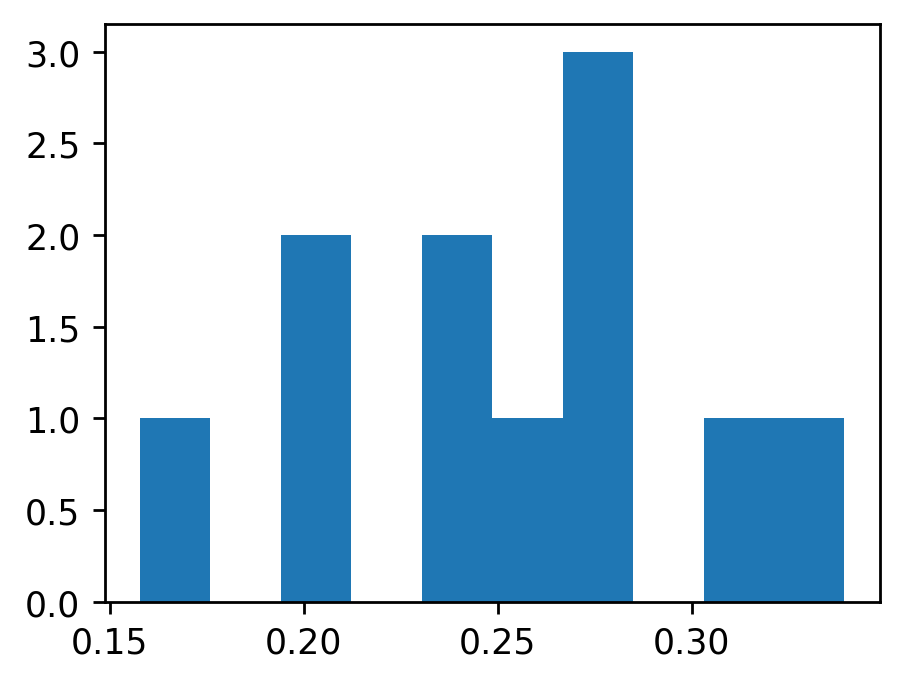

In [32]:
print(len(df_to_write['vid'].unique()))
print(len(df_to_write))

for vid in df_to_write['vid'].unique():
    df_filter = df_to_write[df_to_write['vid'] == vid]

    if len(df_filter)>10:

        fig, ax = plt.subplots(figsize = (4,3), dpi = 250)

        ax.hist(df_filter['Rolling_diff'])
    

In [33]:
df_public_session = pd.read_csv('evwatts.public.session.csv')

df_public_session.head()

,session_id,evse_id,connector_id,start_datetime,end_datetime,total_duration,charge_duration,energy_kwh,start_soc,end_soc,flag_id
0,11562,5,5,2020-03-01 09:37:44,2020-03-01 11:14:59,1.621389,1.615556,6.170,NaN,NaN,0
1,11563,116,116,2020-03-01 10:02:24,2020-03-01 11:08:14,1.096944,1.089722,5.212,NaN,NaN,0
2,11564,72,72,2020-03-01 10:06:08,2020-03-01 11:08:10,1.033611,1.024722,3.392,NaN,NaN,0
3,11565,1,1,2020-03-01 10:01:12,2020-03-01 11:07:09,1.099722,1.076111,6.521,NaN,NaN,0
4,11566,0,138,2020-02-29 19:09:03,2020-03-01 10:47:16,15.636667,12.658889,80.527,NaN,NaN,0


13937235
479671


(array([5565290., 2098841., 1271266.,  780929.,  934576.,  719891.,
         685829.,  519607.,  357085.,  237961.,  169897.,  116392.,
              0.,       0.,       0.,       0.,       0.,       0.,
              0.,       0.,       0.,       0.,       0.,       0.,
              0.,       0.,       0.,       0.,       0.,       0.,
              0.,       0.,       0.,       0.,       0.,       0.,
              0.,       0.,       0.,       0.,       0.,       0.,
              0.,       0.,       0.,       0.,       0.,       0.,
              0.,       0.]),
 array([  0.,   2.,   4.,   6.,   8.,  10.,  12.,  14.,  16.,  18.,  20.,
         22.,  24.,  26.,  28.,  30.,  32.,  34.,  36.,  38.,  40.,  42.,
         44.,  46.,  48.,  50.,  52.,  54.,  56.,  58.,  60.,  62.,  64.,
         66.,  68.,  70.,  72.,  74.,  76.,  78.,  80.,  82.,  84.,  86.,
         88.,  90.,  92.,  94.,  96.,  98., 100.]),
 <BarContainer object of 50 artists>)

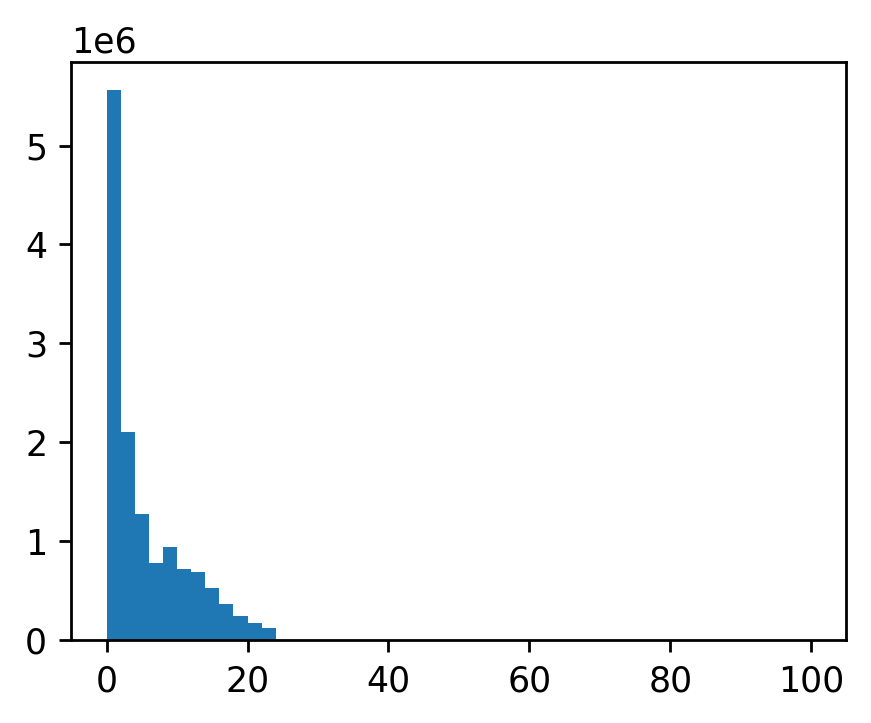

In [42]:
print(len(df_public_session))

df_filter = df_public_session[df_public_session['total_duration']<24]
print(len(df_public_session) - len(df_filter))

fig, ax = plt.subplots(figsize = (4,3), dpi = 250)

ax.hist(df_filter['total_duration'], bins=50,  range=[0, 100])

In [43]:
print(np.mean(df_filter['total_duration']))
print(np.std(df_filter['total_duration']))

5.333204187801859
5.619781893732504
